# ***Importing Libraries***

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder,LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier,GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix,ConfusionMatrixDisplay, classification_report, precision_score, recall_score,f1_score, roc_auc_score

# ***Exploratory Data Analysis (EDA)***

In [ ]:
df = pd.read_csv("data.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
df.drop(['id','Unnamed: 32'], axis=1, inplace=True)

In [ ]:
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [ ]:
df.shape

(569, 31)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [ ]:
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [ ]:
df['diagnosis'].describe()

,diagnosis
count,569
unique,2
top,B
freq,357


In [ ]:
df["diagnosis"].value_counts()

,count
diagnosis,
B,357
M,212


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isna().sum()

,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0


In [ ]:
num_df = df.select_dtypes(include="number")

In [ ]:
num_df.corr()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
radius_mean,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness_mean,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity_mean,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave points_mean,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
symmetry_mean,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921,...,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413
fractal_dimension_mean,-0.311631,-0.076437,-0.261477,-0.283110,0.584792,0.565369,0.336783,0.166917,0.479921,1.000000,...,-0.253691,-0.051269,-0.205151,-0.231854,0.504942,0.458798,0.346234,0.175325,0.334019,0.767297


In [ ]:
num_df.cov()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
radius_mean,12.418920,4.907582,85.447142,1224.483409,0.008454,0.094197,0.190128,0.112475,0.014273,-7.753706e-03,...,16.513749,6.433100,114.288570,1888.227223,0.009625,0.229249,0.387386,0.172393,0.035746,0.000450
texture_mean,4.907582,18.498909,34.439759,485.993787,-0.001415,0.053767,0.103692,0.048977,0.008419,-2.321158e-03,...,7.329267,24.110148,51.745933,841.283832,0.007611,0.188010,0.270110,0.083491,0.027942,0.009260
perimeter_mean,85.447142,34.439759,590.440480,8435.772345,0.070836,0.714714,1.387234,0.802360,0.121922,-4.485888e-02,...,113.858063,45.258113,792.328208,13026.148359,0.083526,1.742478,2.858506,1.231848,0.284300,0.022391
area_mean,1224.483409,485.993787,8435.772345,123843.554318,0.876178,9.264931,19.244924,11.241958,1.459596,-7.034264e-01,...,1637.521341,621.824934,11341.789807,192192.557633,0.992514,21.616602,37.634415,16.701789,3.125809,0.023756
smoothness_mean,0.008454,-0.001415,0.070836,0.876178,0.000198,0.000490,0.000585,0.000302,0.000215,5.806859e-05,...,0.014487,0.003118,0.112879,1.655299,0.000259,0.001045,0.001276,0.000465,0.000343,0.000127
compactness_mean,0.094197,0.053767,0.714714,9.264931,0.000490,0.002789,0.003718,0.001703,0.000873,2.108131e-04,...,0.136643,0.080544,1.047413,15.323436,0.000682,0.007194,0.008994,0.002831,0.001667,0.000656
concavity_mean,0.190128,0.103692,1.387234,19.244924,0.000585,0.003718,0.006355,0.002850,0.001094,1.895588e-04,...,0.265181,0.146934,1.954350,30.682405,0.000817,0.009469,0.014704,0.004513,0.002020,0.000741
concave points_mean,0.112475,0.048977,0.802360,11.241958,0.000302,0.001703,0.002850,0.001506,0.000492,4.572905e-05,...,0.155721,0.069819,1.116016,17.886881,0.000401,0.004075,0.006091,0.002321,0.000902,0.000258
symmetry_mean,0.014273,0.008419,0.121922,1.459596,0.000215,0.000873,0.001094,0.000492,0.000752,9.289106e-05,...,0.024609,0.015274,0.201896,2.765725,0.000267,0.002041,0.002481,0.000775,0.001187,0.000217
fractal_dimension_mean,-0.007754,-0.002321,-0.044859,-0.703426,0.000058,0.000211,0.000190,0.000046,0.000093,4.984872e-05,...,-0.008657,-0.002225,-0.048671,-0.932024,0.000081,0.000510,0.000510,0.000081,0.000146,0.000098


In [ ]:
num_df.skew()

,0
radius_mean,0.942380
texture_mean,0.650450
perimeter_mean,0.990650
area_mean,1.645732
smoothness_mean,0.456324
compactness_mean,1.190123
concavity_mean,1.401180
concave points_mean,1.171180
symmetry_mean,0.725609
fractal_dimension_mean,1.304489


In [ ]:
num_df.kurtosis()

,0
radius_mean,0.845522
texture_mean,0.758319
perimeter_mean,0.972214
area_mean,3.652303
smoothness_mean,0.855975
compactness_mean,1.650130
concavity_mean,1.998638
concave points_mean,1.066556
symmetry_mean,1.287933
fractal_dimension_mean,3.005892


In [ ]:
num_df.var()

,0
radius_mean,12.418920
texture_mean,18.498909
perimeter_mean,590.440480
area_mean,123843.554318
smoothness_mean,0.000198
compactness_mean,0.002789
concavity_mean,0.006355
concave points_mean,0.001506
symmetry_mean,0.000752
fractal_dimension_mean,0.000050


# *Data Visaulization*

<Axes: >

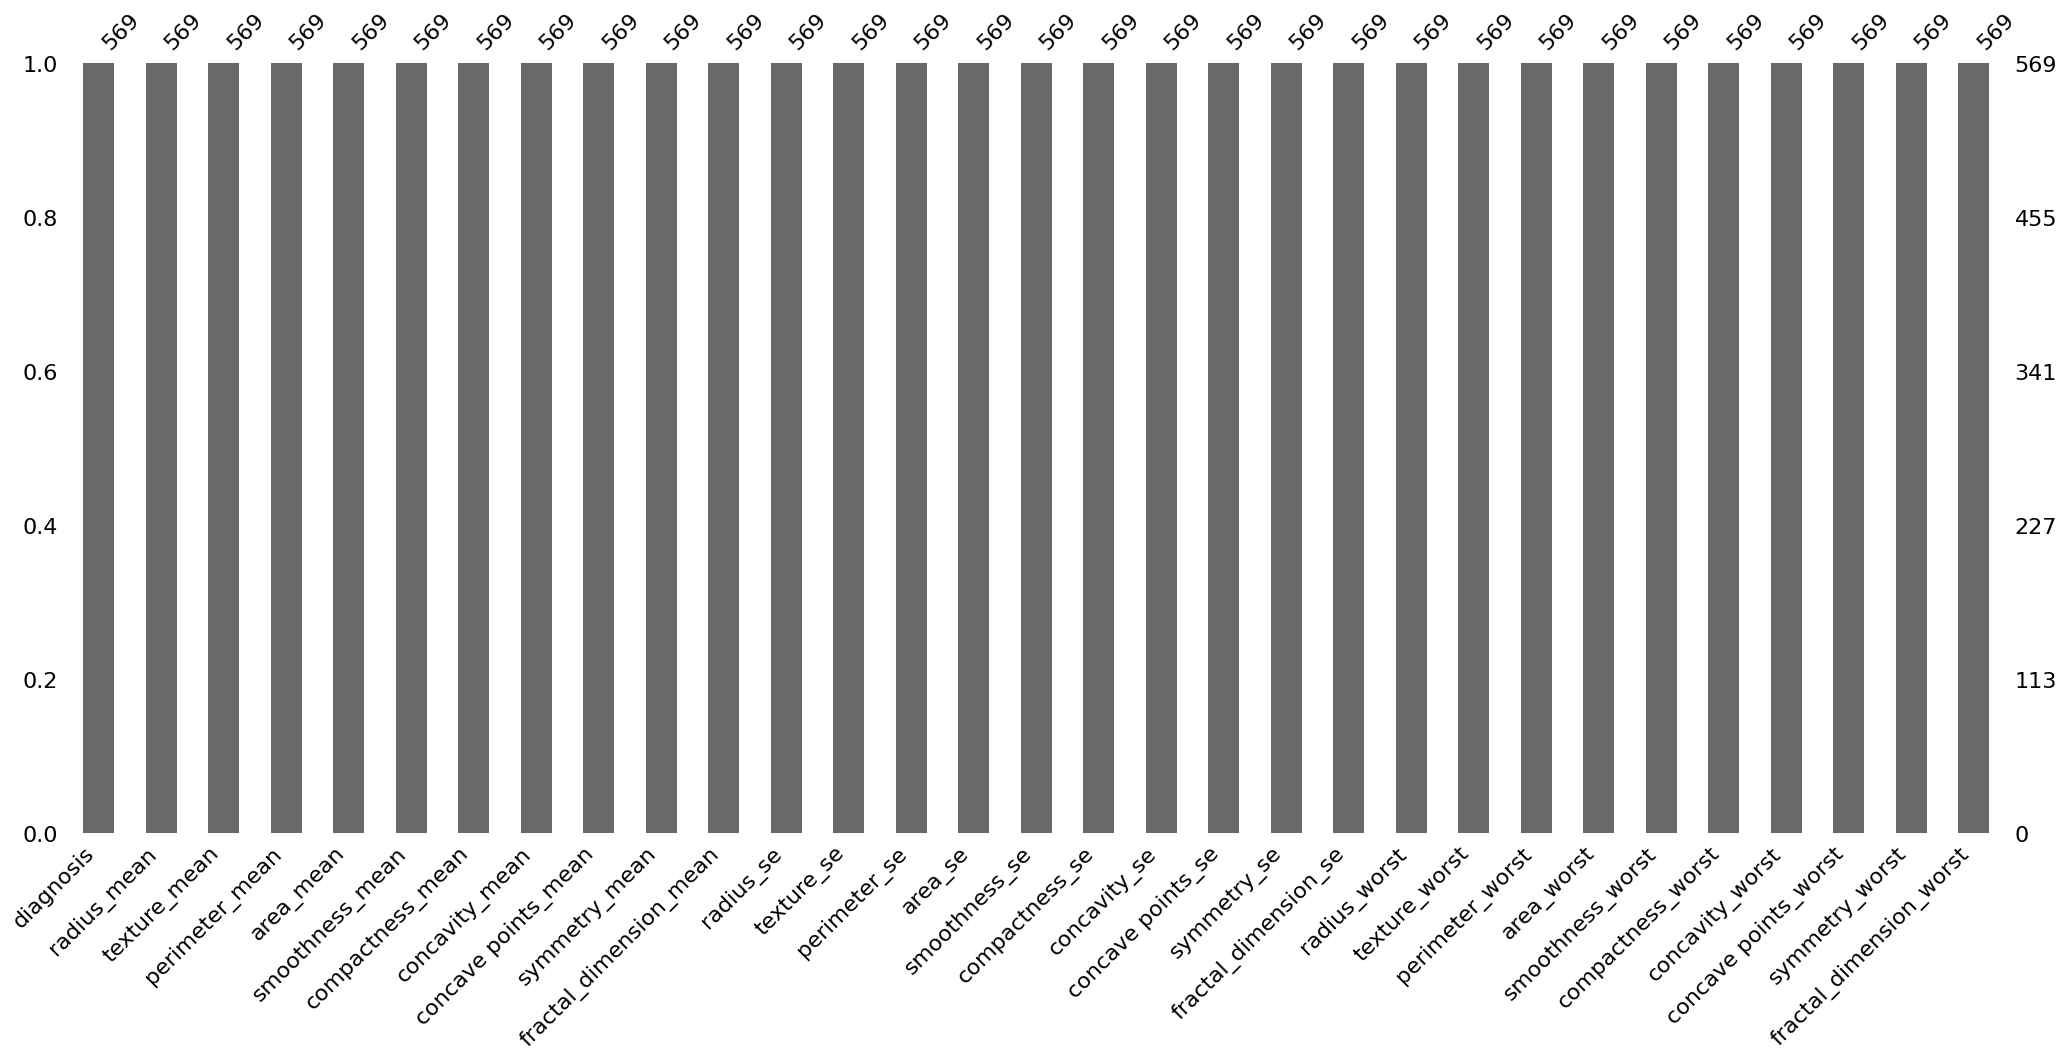

In [ ]:
import missingno
missingno.bar(df)

<Axes: >

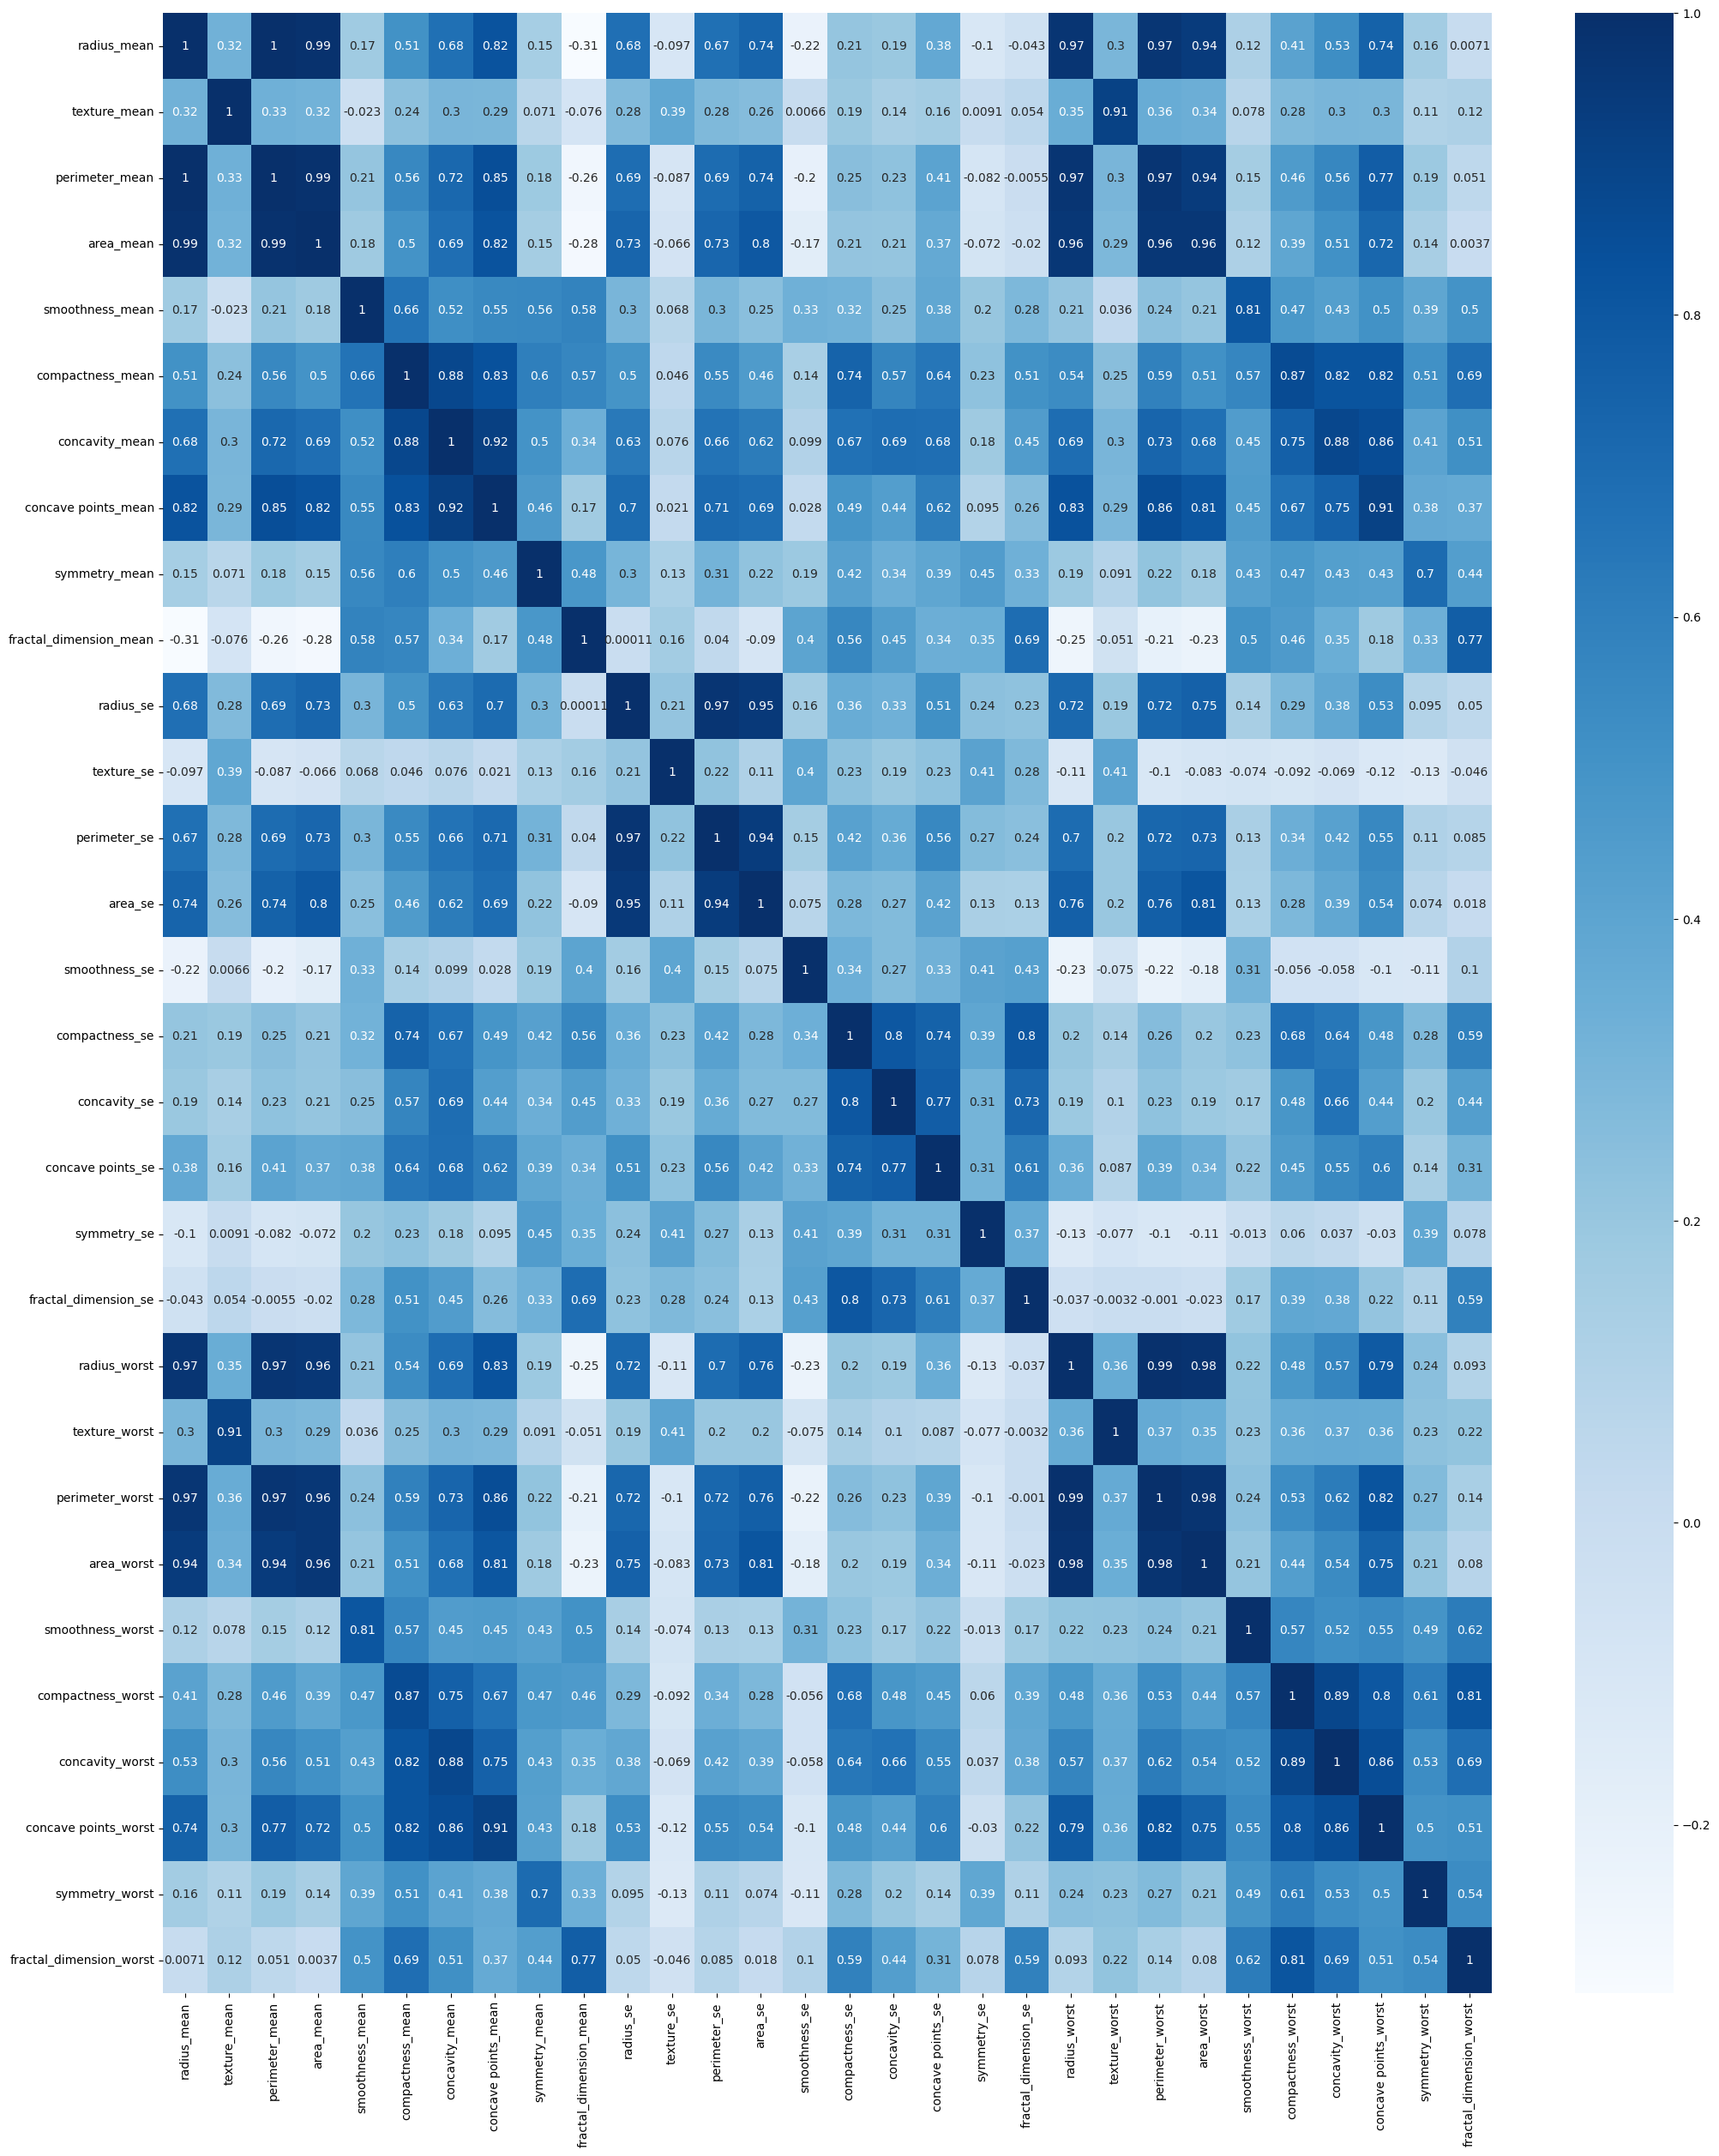

In [ ]:
plt.figure(figsize=(25,30))
sns.heatmap( num_df.corr(),annot=True,cmap='Blues')

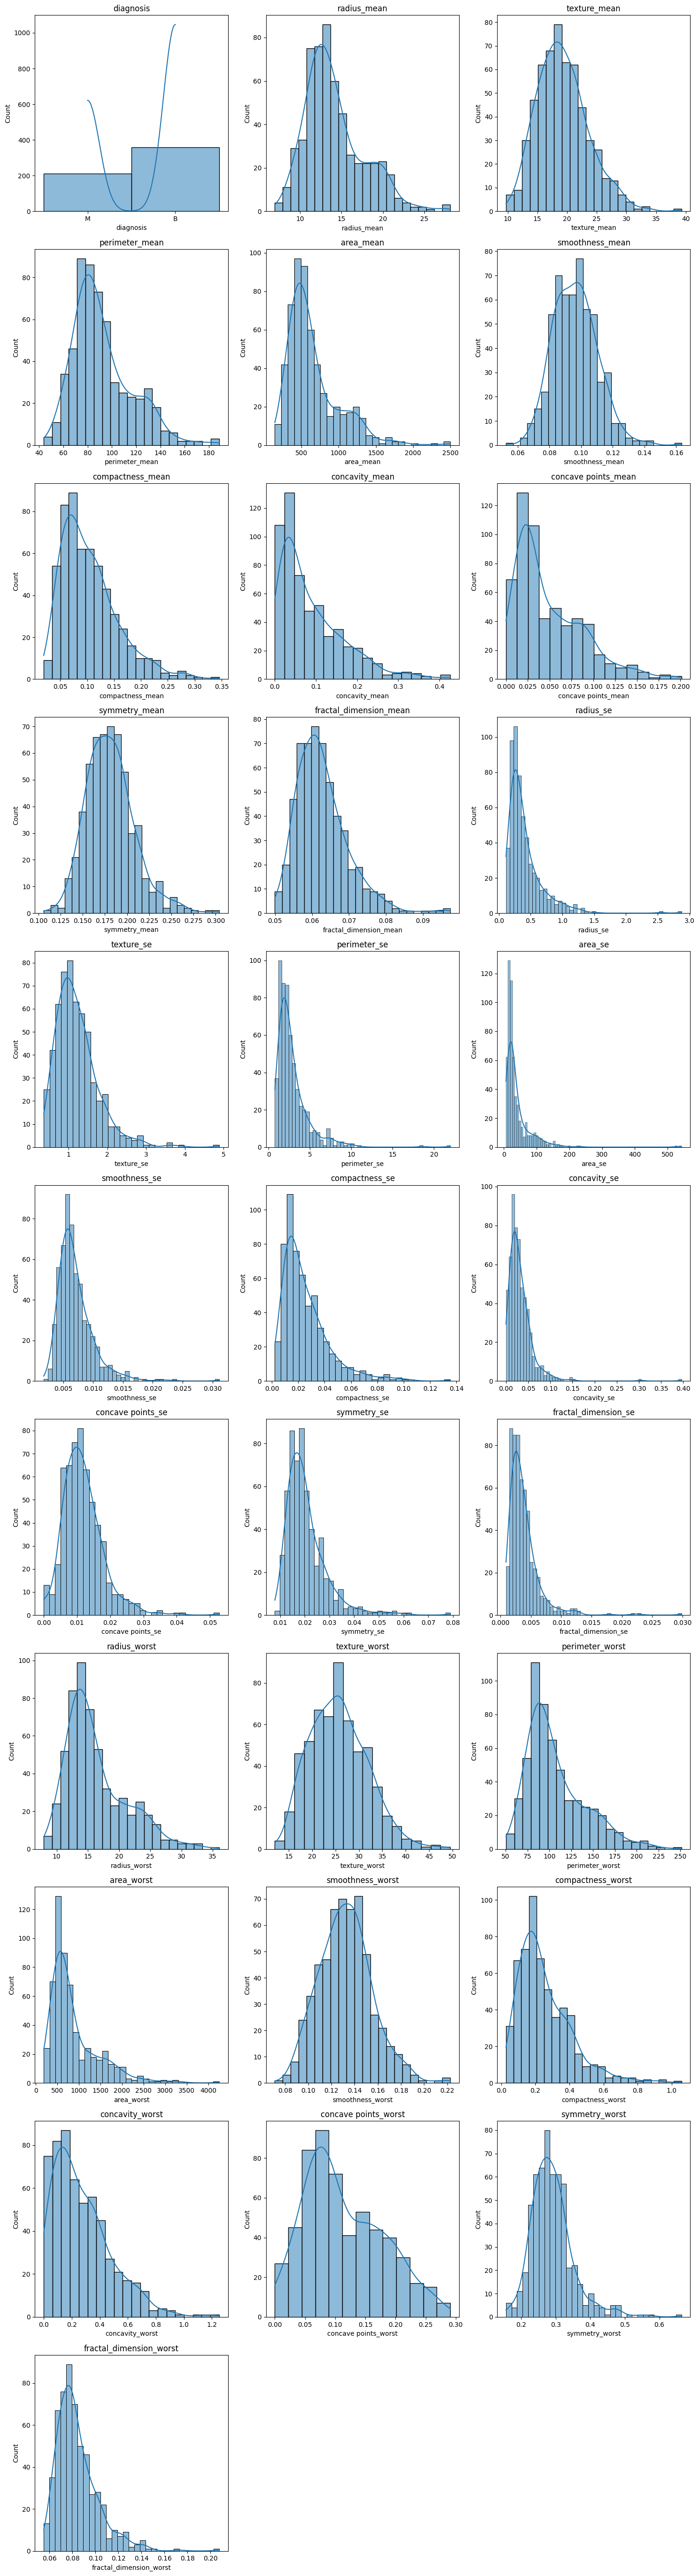

In [ ]:
cols = df.columns
n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

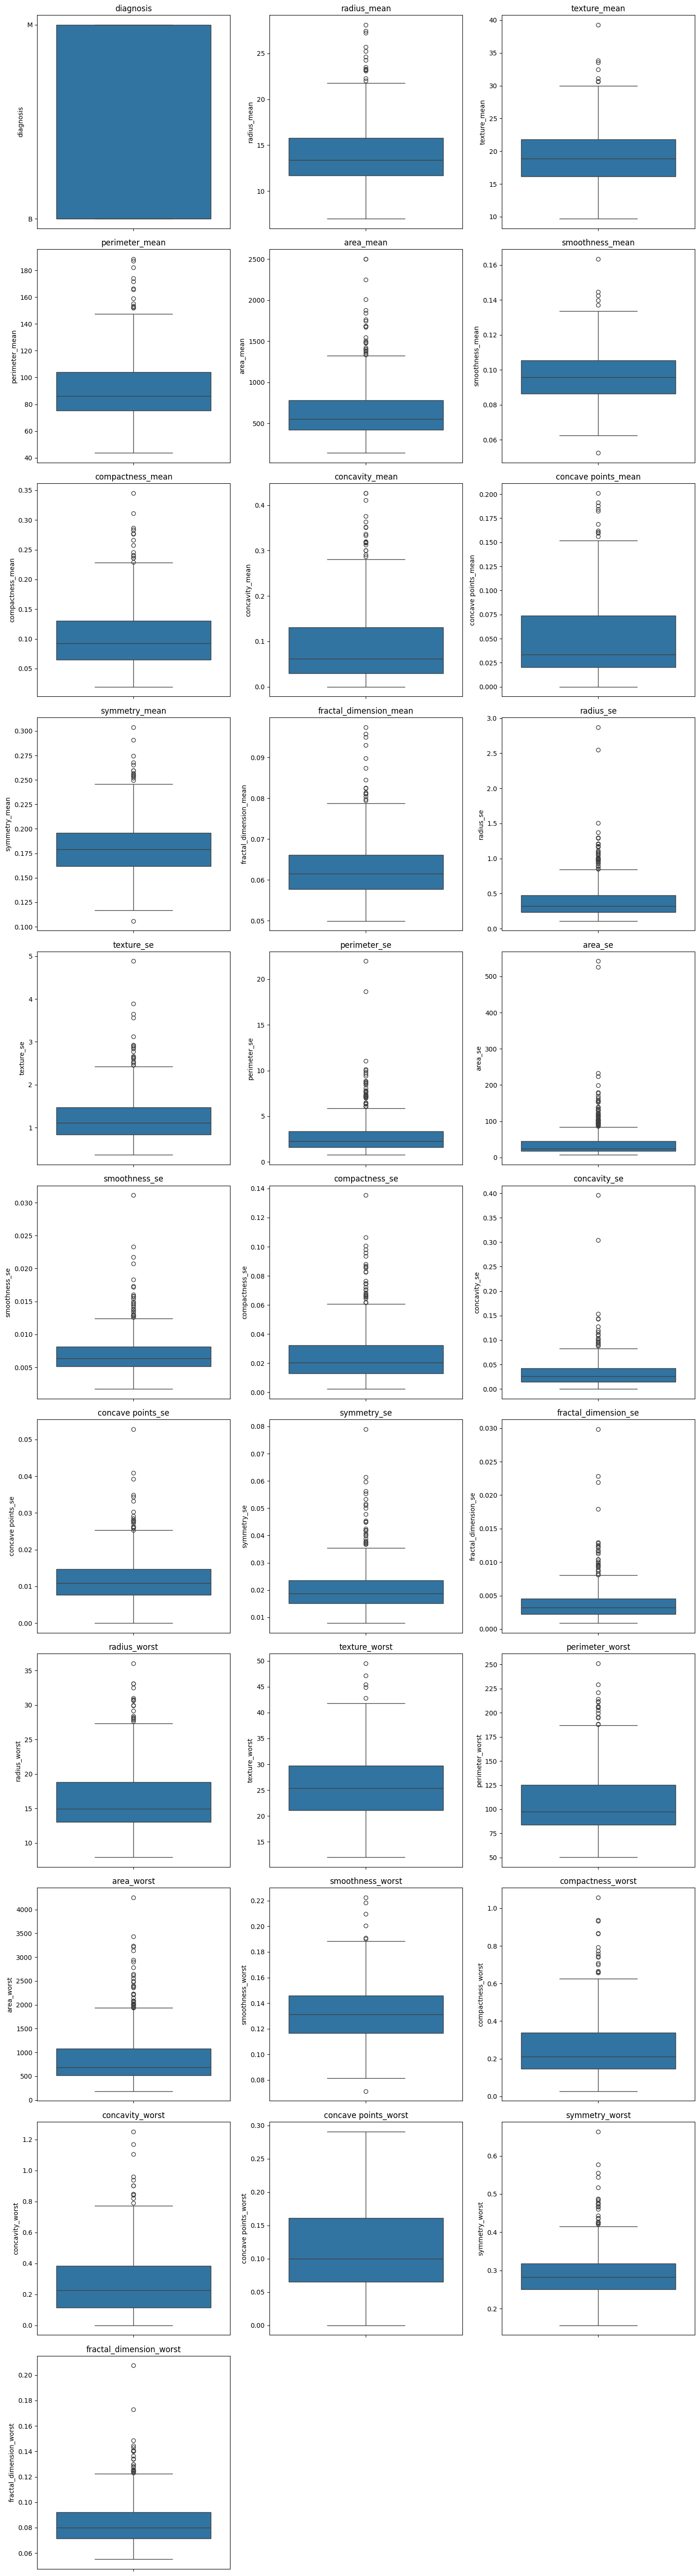

In [ ]:
cols = df.columns
n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

# ***Data Preprocessing***

In [ ]:
for col in num_df:
    Q1 = num_df[col].quantile(0.25)
    Q3 = num_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    num_df[col] = num_df[col].clip(lower, upper)


In [ ]:
df["diagnosis"] = df["diagnosis"].map({"M":1,"B":0})
df["diagnosis"].dtype

dtype('int64')

In [ ]:
X = df.drop("diagnosis",axis=1)
y = df["diagnosis"]

In [43]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

print(y.value_counts())
print(y_resampled.value_counts())

diagnosis
0    357
1    212
Name: count, dtype: int64
diagnosis
1    357
0    357
Name: count, dtype: int64


In [44]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [53]:
models = {
    "KNN": (
        KNeighborsClassifier(),
        {
            'n_neighbors': [3,5,7,9],
            'weights': ['uniform','distance']
        }
    ),

    "LogisticRegression": (
        LogisticRegression(max_iter=1000,class_weight='balanced'),
        {
            'C': [0.01,0.1,1,10]
        }
    ),

    "DecisionTree": (
        DecisionTreeClassifier(class_weight='balanced'),
        {
            'max_depth': [None,5,10,20],
            'min_samples_split': [2,5,10]
        }
    ),

    "RandomForest": (
        RandomForestClassifier(class_weight='balanced'),
        {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 5, 7],
            'min_samples_split': [2, 5]
        }
    ),

    "GradientBoosting": (
        GradientBoostingClassifier(),
        {
            'n_estimators': [100,200],
            'learning_rate': [0.01,0.1]
        }
    ),

    "AdaBoost": (
        AdaBoostClassifier(),
        {
            'n_estimators': [50,100],
            'learning_rate': [0.01,0.1,1]
        }
    ),

    "ExtraTrees": (
        ExtraTreesClassifier(),
        {
            'n_estimators': [100,200],
            'max_depth': [None,10,20]
        }
    ),

    "XGBoost": (
        XGBClassifier(eval_metric='logloss', use_label_encoder=False),
        {
            'n_estimators': [100,200],
            'learning_rate': [0.01,0.1],
            'max_depth': [3,6]
        }
    ),

    "LightGBM": (
        LGBMClassifier(),
        {
            'n_estimators': [100,200],
            'learning_rate': [0.01,0.1]
        }
    ),

    "CatBoost": (
        CatBoostClassifier(verbose=0),
        {
            'iterations': [100,200],
            'learning_rate': [0.01,0.1],
            'depth': [4,6]
        }
    )
}

In [ ]:
results = []

for name, (model, param_grid) in models.items():

    print(f"Training {name}...")

    grid = GridSearchCV(
        model,
        param_grid,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    best_params = grid.best_params_

    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)

    if hasattr(best_model, "predict_proba"):
        roc_auc = roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1])
    else:
        roc_auc = np.nan

    results.append({
        "Model": name,
        "Best Params": best_params,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc,
    })

In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Recall", ascending=False).reset_index(drop=True)
results_df

,Model,Best Params,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,KNN,"{'n_neighbors': 7, 'weights': 'distance'}",1.000000,0.972028,0.948718,1.000000,0.973684,0.998237
1,AdaBoost,"{'learning_rate': 1, 'n_estimators': 100}",1.000000,0.979021,0.961039,1.000000,0.980132,0.998433
2,LightGBM,"{'learning_rate': 0.1, 'n_estimators': 200}",1.000000,0.979021,0.961039,1.000000,0.980132,0.999608
3,XGBoost,"{'learning_rate': 0.1, 'max_depth': 6, 'n_esti...",1.000000,0.972028,0.948718,1.000000,0.973684,0.999608
4,LogisticRegression,{'C': 1},0.977233,0.979021,0.973333,0.986486,0.979866,0.999412
5,RandomForest,"{'max_depth': 7, 'min_samples_split': 2, 'n_es...",1.000000,0.979021,0.973333,0.986486,0.979866,0.996083
6,ExtraTrees,"{'max_depth': 20, 'n_estimators': 200}",1.000000,0.986014,0.986486,0.986486,0.986486,0.998042
7,GradientBoosting,"{'learning_rate': 0.1, 'n_estimators': 200}",1.000000,0.972028,0.960526,0.986486,0.973333,0.999021
8,CatBoost,"{'depth': 4, 'iterations': 200, 'learning_rate...",1.000000,0.979021,0.973333,0.986486,0.979866,0.999412
9,DecisionTree,"{'max_depth': 5, 'min_samples_split': 10}",0.996497,0.951049,0.958904,0.945946,0.952381,0.950450


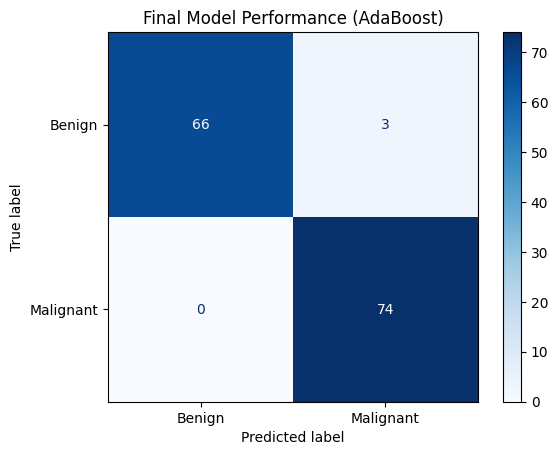

In [ ]:
final_model = AdaBoostClassifier(learning_rate= 1, n_estimators= 100)
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)


cm = confusion_matrix(y_test, y_pred)


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
disp.plot(cmap='Blues')
plt.title('Final Model Performance (AdaBoost)')
plt.show()

/tmp/ipykernel_256/579241088.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


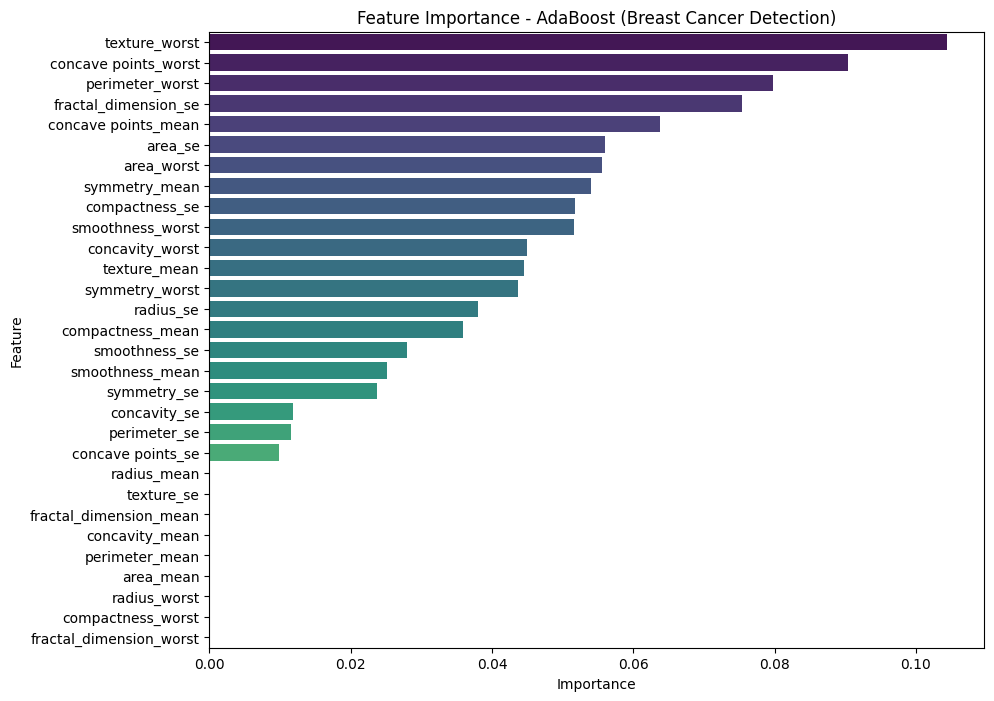

In [ ]:
importances = final_model.feature_importances_
feature_names = X.columns 

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance - AdaBoost (Breast Cancer Detection)')
plt.show()

In [93]:
print(feature_importance_df)

                    Feature  Importance
21            texture_worst    0.104464
27     concave points_worst    0.090351
22          perimeter_worst    0.079830
19     fractal_dimension_se    0.075446
7       concave points_mean    0.063814
13                  area_se    0.055978
23               area_worst    0.055524
8             symmetry_mean    0.054044
15           compactness_se    0.051675
24         smoothness_worst    0.051546
26          concavity_worst    0.044955
1              texture_mean    0.044546
28           symmetry_worst    0.043705
10                radius_se    0.038080
5          compactness_mean    0.035915
14            smoothness_se    0.028028
4           smoothness_mean    0.025189
18              symmetry_se    0.023655
16             concavity_se    0.011855
12             perimeter_se    0.011554
17        concave points_se    0.009846
0               radius_mean    0.000000
11               texture_se    0.000000
9    fractal_dimension_mean    0.000000


In [94]:
import joblib

joblib.dump(final_model, 'breast_cancer_adaboost_final.pkl')

joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']